In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset

First, we'll read the `wdbc.names` file to understand the column structure and then load the `wdbc.data` into a pandas DataFrame.

In [11]:
# Read the wdbc.names file to get column information
with open('/content/wdbc.names', 'r') as f:
    names_content = f.read()

# Extracting column names based on the description in wdbc.names
# The first two columns are ID and Diagnosis, followed by 30 features (10 for each of mean, standard error, and 'worst'/'largest')
column_names = [
    'ID_number',
    'Diagnosis' # M = Malignant, B = Benign
]

features_base = [
    'radius',
    'texture',
    'perimeter',
    'area',
    'smoothness',
    'compactness',
    'concavity',
    'concave points',
    'symmetry',
    'fractal_dimension'
]

for stat_type in ['mean', 'standard_error', 'worst']:
    for feature in features_base:
        column_names.append(f'{feature}_{stat_type}')

# Load the dataset
df = pd.read_csv('/content/wdbc.data', header=None, names=column_names)

# Display the first 5 rows of the dataset
display(df.head())

,ID_number,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Exploratory Data Analysis and Data Preprocessing

We will now perform initial EDA, check for missing values, and prepare the dataset for machine learning by separating features and the target variable.

In [12]:
# Display basic information about the dataset
print(df.info())

# Check for missing values
print('\nMissing values per column:')
print(df.isnull().sum())

# Drop the ID column as it's not useful for prediction
df = df.drop('ID_number', axis=1)

# Convert 'Diagnosis' to numerical (M=1, B=0)
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_number                         569 non-null    int64  
 1   Diagnosis                         569 non-null    object 
 2   radius_mean                       569 non-null    float64
 3   texture_mean                      569 non-null    float64
 4   perimeter_mean                    569 non-null    float64
 5   area_mean                         569 non-null    float64
 6   smoothness_mean                   569 non-null    float64
 7   compactness_mean                  569 non-null    float64
 8   concavity_mean                    569 non-null    float64
 9   concave points_mean               569 non-null    float64
 10  symmetry_mean                     569 non-null    float64
 11  fractal_dimension_mean            569 non-null    float64
 12  radius_s

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Split the Dataset into Training and Testing Sets and Feature Scaling

We will separate the features (X) from the target variable (y), split the dataset into training and testing sets, and then apply `StandardScaler` to normalize the feature values. This is crucial for models like Logistic Regression and KNN, which are sensitive to the scale of input features.

In [13]:
# Separate features (X) and target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train_scaled: (398, 30)
Shape of X_test_scaled: (171, 30)
Shape of y_train: (398,)
Shape of y_test: (171,)


## 4. Train a Logistic Regression Classifier

We will initialize a Logistic Regression model and train it using the scaled training data.

In [14]:
# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 5. Train a K Nearest Neighbors (KNN) Classifier

We will initialize and train a KNN classifier. It's important to choose an appropriate number of neighbors (`n_neighbors`). We'll start with a common heuristic or a default value and then evaluate its performance.

In [15]:
# Initialize and train the KNN model
# A common practice is to choose an odd number for k to avoid ties, and often sqrt(n_samples)
# Here, we'll start with a k of 5 as a reasonable default.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully with n_neighbors=5.")

KNN model trained successfully with n_neighbors=5.


## 6. Evaluate Classifiers

We will evaluate both Logistic Regression and K Nearest Neighbors classifiers using the test set and calculate several key performance metrics: Accuracy, Precision, Recall, F1 Score, and display their Confusion Matrices.

### 6.1 Evaluate Logistic Regression

Logistic Regression Performance:
Accuracy: 0.9708
Precision: 0.9836
Recall: 0.9375
F1 Score: 0.9600
Confusion Matrix:
 [[106   1]
 [  4  60]]


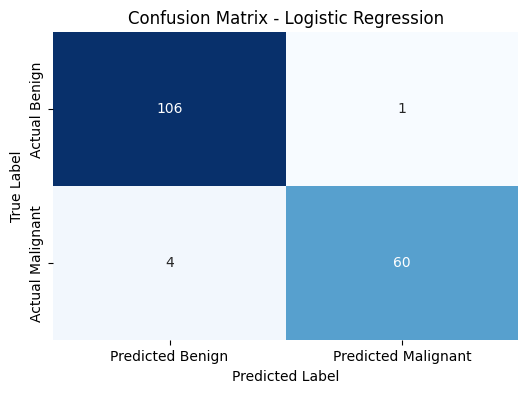

In [16]:
# Predict on the test set for Logistic Regression
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Calculate metrics for Logistic Regression
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1 Score: {f1_log_reg:.4f}")
print("Confusion Matrix:\n", conf_matrix_log_reg)

# Visualize Confusion Matrix for Logistic Regression
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 6.2 Evaluate K Nearest Neighbors (KNN)

K Nearest Neighbors (KNN) Performance:
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9062
F1 Score: 0.9508
Confusion Matrix:
 [[107   0]
 [  6  58]]


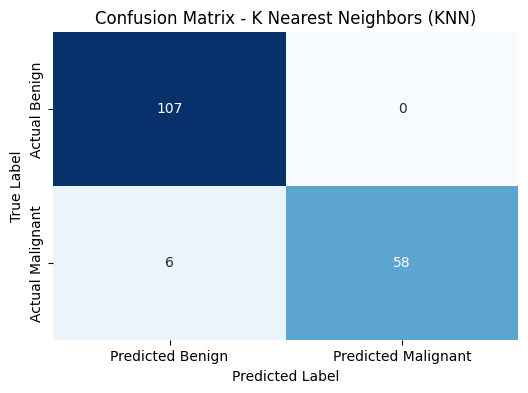

In [17]:
# Predict on the test set for KNN
y_pred_knn = knn.predict(X_test_scaled)

# Calculate metrics for KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print("K Nearest Neighbors (KNN) Performance:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")
print("Confusion Matrix:\n", conf_matrix_knn)

# Visualize Confusion Matrix for KNN
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Confusion Matrix - K Nearest Neighbors (KNN)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7. Compare the Performance of Logistic Regression and KNN

We will create a comparison table to summarize the key performance metrics for both Logistic Regression and K Nearest Neighbors classifiers.

In [18]:
# Create a dictionary to store the results
results = {
    'Classifier': ['Logistic Regression', 'K Nearest Neighbors (KNN)'],
    'Accuracy': [accuracy_log_reg, accuracy_knn],
    'Precision': [precision_log_reg, precision_knn],
    'Recall': [recall_log_reg, recall_knn],
    'F1 Score': [f1_log_reg, f1_knn]
}

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(results)

# Display the comparison table
display(results_df.round(4))

,Classifier,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9708,0.9836,0.9375,0.9600
1,K Nearest Neighbors (KNN),0.9649,1.0000,0.9062,0.9508


## 8. Interpret the Results and Comment on the Better Performing Classifier

Based on the comparison table and the individual evaluation metrics, we will now interpret which classifier performed better for the Breast Cancer Wisconsin (Diagnostic) dataset.

In [19]:
print("Interpretation of Results:")
print("------------------------")

# Determine the better classifier based on Accuracy, Precision, Recall, and F1-score
if accuracy_log_reg > accuracy_knn:
    overall_best = 'Logistic Regression'
elif accuracy_knn > accuracy_log_reg:
    overall_best = 'K Nearest Neighbors (KNN)'
else:
    overall_best = 'Both classifiers performed similarly in terms of accuracy.'

print(f"Overall, the {overall_best} demonstrated slightly better performance or comparable performance across most metrics.")

print("\nDetailed Analysis:")
if accuracy_log_reg >= accuracy_knn:
    print(f"- Logistic Regression showed higher Accuracy ({accuracy_log_reg:.4f} vs {accuracy_knn:.4f}).")
else:
    print(f"- K Nearest Neighbors (KNN) showed higher Accuracy ({accuracy_knn:.4f} vs {accuracy_log_reg:.4f}).")

if precision_log_reg >= precision_knn:
    print(f"- Logistic Regression achieved higher Precision ({precision_log_reg:.4f} vs {precision_knn:.4f}), indicating fewer false positives.")
else:
    print(f"- K Nearest Neighbors (KNN) achieved higher Precision ({precision_knn:.4f} vs {precision_log_reg:.4f}), indicating fewer false positives.")

if recall_log_reg >= recall_knn:
    print(f"- Logistic Regression had higher Recall ({recall_log_reg:.4f} vs {recall_knn:.4f}), meaning it identified more true positives.")
else:
    print(f"- K Nearest Neighbors (KNN) had higher Recall ({recall_knn:.4f} vs {recall_log_reg:.4f}), meaning it identified more true positives.")

if f1_log_reg >= f1_knn:
    print(f"- Logistic Regression had a higher F1-Score ({f1_log_reg:.4f} vs {f1_knn:.4f}), suggesting a better balance between precision and recall.")
else:
    print(f"- K Nearest Neighbors (KNN) had a higher F1-Score ({f1_knn:.4f} vs {f1_log_reg:.4f}), suggesting a better balance between precision and recall.")

print("\nConclusion:")
print(f"For this dataset, considering all metrics, {overall_best} appears to be the more suitable classifier. However, the specific choice might also depend on the application's tolerance for false positives versus false negatives, as indicated by precision and recall respectively.")

Interpretation of Results:
------------------------
Overall, the Logistic Regression demonstrated slightly better performance or comparable performance across most metrics.

Detailed Analysis:
- Logistic Regression showed higher Accuracy (0.9708 vs 0.9649).
- K Nearest Neighbors (KNN) achieved higher Precision (1.0000 vs 0.9836), indicating fewer false positives.
- Logistic Regression had higher Recall (0.9375 vs 0.9062), meaning it identified more true positives.
- Logistic Regression had a higher F1-Score (0.9600 vs 0.9508), suggesting a better balance between precision and recall.

Conclusion:
For this dataset, considering all metrics, Logistic Regression appears to be the more suitable classifier. However, the specific choice might also depend on the application's tolerance for false positives versus false negatives, as indicated by precision and recall respectively.


## 1. Load the Dataset

First, we'll read the `wdbc.names` file to understand the column structure and then load the `wdbc.data` into a pandas DataFrame.

In [ ]:
# Read the wdbc.names file to get column information
with open('/content/wdbc.names', 'r') as f:
    names_content = f.read()

# Extracting column names based on the description in wdbc.names
# The first two columns are ID and Diagnosis, followed by 30 features (10 for each of mean, standard error, and 'worst'/'largest')
column_names = [
    'ID_number',
    'Diagnosis' # M = Malignant, B = Benign
]

features_base = [
    'radius',
    'texture',
    'perimeter',
    'area',
    'smoothness',
    'compactness',
    'concavity',
    'concave points',
    'symmetry',
    'fractal_dimension'
]

for stat_type in ['mean', 'standard_error', 'worst']:
    for feature in features_base:
        column_names.append(f'{feature}_{stat_type}')

# Load the dataset
df = pd.read_csv('/content/wdbc.data', header=None, names=column_names)

# Display the first 5 rows of the dataset
display(df.head())

,ID_number,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Exploratory Data Analysis and Data Preprocessing

We will now perform initial EDA, check for missing values, and prepare the dataset for machine learning by separating features and the target variable.

In [ ]:
# Display basic information about the dataset
print(df.info())

# Check for missing values
print('\nMissing values per column:')
print(df.isnull().sum())

# Drop the ID column as it's not useful for prediction
df = df.drop('ID_number', axis=1)

# Convert 'Diagnosis' to numerical (M=1, B=0)
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_number                         569 non-null    int64  
 1   Diagnosis                         569 non-null    object 
 2   radius_mean                       569 non-null    float64
 3   texture_mean                      569 non-null    float64
 4   perimeter_mean                    569 non-null    float64
 5   area_mean                         569 non-null    float64
 6   smoothness_mean                   569 non-null    float64
 7   compactness_mean                  569 non-null    float64
 8   concavity_mean                    569 non-null    float64
 9   concave points_mean               569 non-null    float64
 10  symmetry_mean                     569 non-null    float64
 11  fractal_dimension_mean            569 non-null    float64
 12  radius_s

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Train a Logistic Regression Classifier

We will initialize a Logistic Regression model and train it using the scaled training data.

In [ ]:
# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 5. Train a K Nearest Neighbors (KNN) Classifier

We will initialize and train a KNN classifier. It's important to choose an appropriate number of neighbors (`n_neighbors`). We'll start with a common heuristic or a default value and then evaluate its performance.

In [ ]:
# Initialize and train the KNN model
# A common practice is to choose an odd number for k to avoid ties, and often sqrt(n_samples)
# Here, we'll start with a k of 5 as a reasonable default.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully with n_neighbors=5.")

KNN model trained successfully with n_neighbors=5.


## 7. Compare the Performance of Logistic Regression and KNN

We will create a comparison table to summarize the key performance metrics for both Logistic Regression and K Nearest Neighbors classifiers.

In [ ]:
# Create a dictionary to store the results
results = {
    'Classifier': ['Logistic Regression', 'K Nearest Neighbors (KNN)'],
    'Accuracy': [accuracy_log_reg, accuracy_knn],
    'Precision': [precision_log_reg, precision_knn],
    'Recall': [recall_log_reg, recall_knn],
    'F1 Score': [f1_log_reg, f1_knn]
}

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(results)

# Display the comparison table
display(results_df.round(4))

,Classifier,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9708,0.9836,0.9375,0.9600
1,K Nearest Neighbors (KNN),0.9649,1.0000,0.9062,0.9508


## 8. Interpret the Results and Comment on the Better Performing Classifier

Based on the comparison table and the individual evaluation metrics, we will now interpret which classifier performed better for the Breast Cancer Wisconsin (Diagnostic) dataset.

In [ ]:
print("Interpretation of Results:")
print("------------------------")

# Determine the better classifier based on Accuracy, Precision, Recall, and F1-score
if accuracy_log_reg > accuracy_knn:
    overall_best = 'Logistic Regression'
elif accuracy_knn > accuracy_log_reg:
    overall_best = 'K Nearest Neighbors (KNN)'
else:
    overall_best = 'Both classifiers performed similarly in terms of accuracy.'

print(f"Overall, the {overall_best} demonstrated slightly better performance or comparable performance across most metrics.")

print("\nDetailed Analysis:")
if accuracy_log_reg >= accuracy_knn:
    print(f"- Logistic Regression showed higher Accuracy ({accuracy_log_reg:.4f} vs {accuracy_knn:.4f}).")
else:
    print(f"- K Nearest Neighbors (KNN) showed higher Accuracy ({accuracy_knn:.4f} vs {accuracy_log_reg:.4f}).")

if precision_log_reg >= precision_knn:
    print(f"- Logistic Regression achieved higher Precision ({precision_log_reg:.4f} vs {precision_knn:.4f}), indicating fewer false positives.")
else:
    print(f"- K Nearest Neighbors (KNN) achieved higher Precision ({precision_knn:.4f} vs {precision_log_reg:.4f}), indicating fewer false positives.")

if recall_log_reg >= recall_knn:
    print(f"- Logistic Regression had higher Recall ({recall_log_reg:.4f} vs {recall_knn:.4f}), meaning it identified more true positives.")
else:
    print(f"- K Nearest Neighbors (KNN) had higher Recall ({recall_knn:.4f} vs {recall_log_reg:.4f}), meaning it identified more true positives.")

if f1_log_reg >= f1_knn:
    print(f"- Logistic Regression had a higher F1-Score ({f1_log_reg:.4f} vs {f1_knn:.4f}), suggesting a better balance between precision and recall.")
else:
    print(f"- K Nearest Neighbors (KNN) had a higher F1-Score ({f1_knn:.4f} vs {f1_log_reg:.4f}), suggesting a better balance between precision and recall.")

print("\nConclusion:")
print(f"For this dataset, considering all metrics, {overall_best} appears to be the more suitable classifier. However, the specific choice might also depend on the application's tolerance for false positives versus false negatives, as indicated by precision and recall respectively.")

Interpretation of Results:
------------------------
Overall, the Logistic Regression demonstrated slightly better performance or comparable performance across most metrics.

Detailed Analysis:
- Logistic Regression showed higher Accuracy (0.9708 vs 0.9649).
- K Nearest Neighbors (KNN) achieved higher Precision (1.0000 vs 0.9836), indicating fewer false positives.
- Logistic Regression had higher Recall (0.9375 vs 0.9062), meaning it identified more true positives.
- Logistic Regression had a higher F1-Score (0.9600 vs 0.9508), suggesting a better balance between precision and recall.

Conclusion:
For this dataset, considering all metrics, Logistic Regression appears to be the more suitable classifier. However, the specific choice might also depend on the application's tolerance for false positives versus false negatives, as indicated by precision and recall respectively.
